In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

base_path = "/content/drive/MyDrive/AyurAI_Model"

folders = [
    "dataset",
    "notebooks",
    "models",
    "results"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("AyurAI project folders created successfully!")

AyurAI project folders created successfully!


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
import os

dataset_path = "/content/drive/MyDrive/AyurAI_Model/dataset"

print(os.listdir(dataset_path))

['Classification (1).tar', 'Classification.tar']


In [6]:
import tarfile

archive_path = "/content/drive/MyDrive/AyurAI_Model/dataset/Classification.tar"

with tarfile.open(archive_path, "r") as archive:
    members = archive.getnames()
    print("Total items:", len(members))
    print("First 10 items:")

    for item in members[:10]:
        print(item)

Total items: 1469
First 10 items:
Classification/JPEGImages/levle0_375.jpg
Classification/JPEGImages/levle2_173.jpg
Classification/JPEGImages/levle0_33.jpg
Classification/JPEGImages/levle0_129.jpg
Classification/JPEGImages/levle0_506.jpg
Classification/JPEGImages/levle1_626.jpg
Classification/JPEGImages/levle1_18.jpg
Classification/JPEGImages/levle1_80.jpg
Classification/JPEGImages/levle3_42.jpg
Classification/JPEGImages/levle1_471.jpg


In [7]:
import os
import tarfile

archive_path = "/content/drive/MyDrive/AyurAI_Model/dataset/Classification.tar"
extract_path = "/content/drive/MyDrive/AyurAI_Model/dataset/ACNE04"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(archive_path, "r") as archive:
    archive.extractall(path=extract_path, filter="data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
import os
from glob import glob
from collections import Counter

acne04_path = "/content/drive/MyDrive/AyurAI_Model/dataset/ACNE04"
image_files = glob(os.path.join(acne04_path, "**", "*.jpg"), recursive=True)

level_counts = Counter()

for image_path in image_files:
    filename = os.path.basename(image_path).lower()

    for level in range(4):
        if f"levle{level}_" in filename:
            level_counts[level] += 1
            break

print("Total JPG images:", len(image_files))

for level in range(4):
    print(f"Level {level}: {level_counts[level]} images")

Total JPG images: 1457
Level 0: 497 images
Level 1: 637 images
Level 2: 186 images
Level 3: 137 images


In [9]:
import os
from glob import glob

acne04_path = "/content/drive/MyDrive/AyurAI_Model/dataset/ACNE04"

all_files = glob(os.path.join(acne04_path, "**", "*"), recursive=True)
non_image_files = [
    path for path in all_files
    if os.path.isfile(path) and not path.lower().endswith(".jpg")
]

print("Non-image files:", len(non_image_files))

for path in non_image_files:
    print(os.path.relpath(path, acne04_path))

Non-image files: 10
Classification/NNEW_trainval_1.txt
Classification/NNEW_test_4.txt
Classification/NNEW_trainval_4.txt
Classification/NNEW_test_2.txt
Classification/NNEW_trainval_2.txt
Classification/NNEW_test_0.txt
Classification/NNEW_trainval_0.txt
Classification/NNEW_test_3.txt
Classification/NNEW_trainval_3.txt
Classification/NNEW_test_1.txt


In [10]:
import os

classification_path = (
    "/content/drive/MyDrive/AyurAI_Model/"
    "dataset/ACNE04/Classification"
)

sample_file = os.path.join(classification_path, "NNEW_trainval_0.txt")

with open(sample_file, "r") as file:
    lines = file.readlines()

print("Number of records:", len(lines))
print("First 10 records:")

for line in lines[:10]:
    print(line.strip())

Number of records: 1165
First 10 records:
levle0_0.jpg  0  3
levle0_1.jpg  0  3
levle0_100.jpg  0  2
levle0_101.jpg  0  1
levle0_102.jpg  0  3
levle0_104.jpg  0  1
levle0_105.jpg  0  1
levle0_106.jpg  0  1
levle0_108.jpg  0  1
levle0_109.jpg  0  1


In [11]:
import os
import pandas as pd

classification_path = (
    "/content/drive/MyDrive/AyurAI_Model/"
    "dataset/ACNE04/Classification"
)

columns = ["filename", "label", "lesion_count"]

train_df = pd.read_csv(
    os.path.join(classification_path, "NNEW_trainval_0.txt"),
    sep=r"\s+",
    names=columns
)

test_df = pd.read_csv(
    os.path.join(classification_path, "NNEW_test_0.txt"),
    sep=r"\s+",
    names=columns
)

print("Training/validation images:", len(train_df))
print("Test images:", len(test_df))

print("\nTraining class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

Training/validation images: 1165
Test images: 292

Training class distribution:
label
0    410
1    506
2    146
3    103
Name: count, dtype: int64

Test class distribution:
label
0    103
1    127
2     36
3     26
Name: count, dtype: int64


In [12]:
import os

images_path = os.path.join(classification_path, "JPEGImages")

train_missing = [
    filename
    for filename in train_df["filename"]
    if not os.path.exists(os.path.join(images_path, filename))
]

test_missing = [
    filename
    for filename in test_df["filename"]
    if not os.path.exists(os.path.join(images_path, filename))
]

overlap = set(train_df["filename"]) & set(test_df["filename"])

print("Missing training images:", len(train_missing))
print("Missing test images:", len(test_missing))
print("Images appearing in both sets:", len(overlap))

Missing training images: 0
Missing test images: 0
Images appearing in both sets: 0


In [13]:
import os
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

splits_path = (
    "/content/drive/MyDrive/AyurAI_Model/results/splits"
)

os.makedirs(splits_path, exist_ok=True)

train_split.to_csv(
    os.path.join(splits_path, "train.csv"),
    index=False
)

val_split.to_csv(
    os.path.join(splits_path, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(splits_path, "test.csv"),
    index=False
)

print("Training images:", len(train_split))
print("Validation images:", len(val_split))
print("Test images:", len(test_df))

print("\nTraining distribution:")
print(train_split["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_split["label"].value_counts().sort_index())

Training images: 932
Validation images: 233
Test images: 292

Training distribution:
label
0    328
1    405
2    117
3     82
Name: count, dtype: int64

Validation distribution:
label
0     82
1    101
2     29
3     21
Name: count, dtype: int64


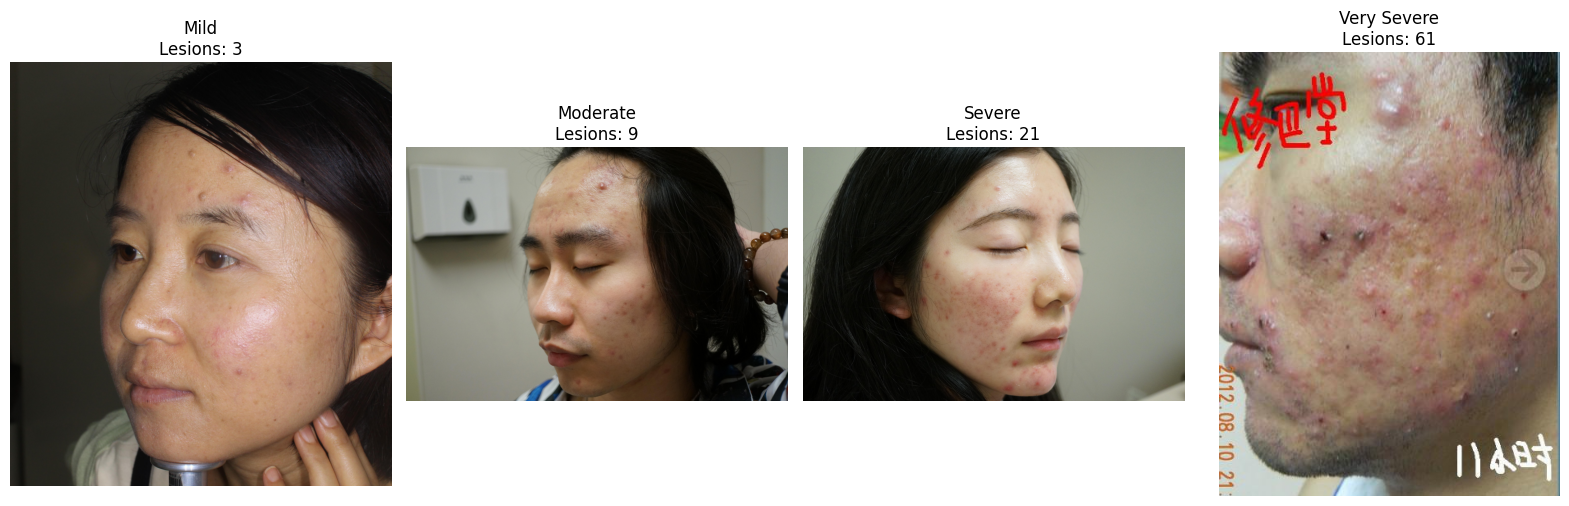

In [14]:
import os
import matplotlib.pyplot as plt
from PIL import Image

label_names = {
    0: "Mild",
    1: "Moderate",
    2: "Severe",
    3: "Very Severe"
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for label, axis in enumerate(axes):
    sample = train_split[
        train_split["label"] == label
    ].sample(1, random_state=42).iloc[0]

    image_path = os.path.join(images_path, sample["filename"])
    image = Image.open(image_path).convert("RGB")

    axis.imshow(image)
    axis.set_title(
        f"{label_names[label]}\n"
        f"Lesions: {sample['lesion_count']}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from torchvision import transforms

image_size = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        image_size,
        scale=(0.80, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training and evaluation transformations created!")

Training and evaluation transformations created!


In [5]:
import os
from PIL import Image
from torch.utils.data import Dataset

class AcneDataset(Dataset):
    def __init__(self, dataframe, images_directory, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_directory = images_directory
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = os.path.join(
            self.images_directory,
            row["filename"]
        )

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

train_dataset = AcneDataset(
    train_split,
    images_path,
    train_transform
)

validation_dataset = AcneDataset(
    val_split,
    images_path,
    evaluation_transform
)

test_dataset = AcneDataset(
    test_df,
    images_path,
    evaluation_transform
)

sample_image, sample_label = train_dataset[0]

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))
print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label)

Training samples: 932
Validation samples: 233
Test samples: 292
Sample image shape: torch.Size([3, 224, 224])
Sample label: 1


In [6]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

batch_images, batch_labels = next(iter(train_loader))

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training batches: 30
Validation batches: 8
Test batches: 10
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [7]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not connected")

GPU available: False
GPU is not connected


In [1]:
import torch

print("GPU available:", torch.cuda.is_available())
print(
    "GPU name:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "Not connected"
)

GPU available: True
GPU name: Tesla T4


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

base_path = "/content/drive/MyDrive/AyurAI_Model"

images_path = os.path.join(
    base_path,
    "dataset/ACNE04/Classification/JPEGImages"
)

splits_path = os.path.join(
    base_path,
    "results/splits"
)

train_split = pd.read_csv(
    os.path.join(splits_path, "train.csv")
)

val_split = pd.read_csv(
    os.path.join(splits_path, "validation.csv")
)

test_df = pd.read_csv(
    os.path.join(splits_path, "test.csv")
)

image_size = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.80, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class AcneDataset(Dataset):
    def __init__(self, dataframe, images_directory, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_directory = images_directory
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = os.path.join(
            self.images_directory,
            row["filename"]
        )

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

train_dataset = AcneDataset(
    train_split, images_path, train_transform
)

validation_dataset = AcneDataset(
    val_split, images_path, evaluation_transform
)

test_dataset = AcneDataset(
    test_df, images_path, evaluation_transform
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Session restored successfully!")
print("Device:", device)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

Mounted at /content/drive
Session restored successfully!
Device: cuda
Training samples: 932
Validation samples: 233
Test samples: 292


In [3]:
import torch.nn as nn
from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

weights = MobileNet_V3_Small_Weights.DEFAULT

model = mobilenet_v3_small(weights=weights)

# Freeze the pretrained feature extractor initially
for parameter in model.features.parameters():
    parameter.requires_grad = False

# Replace ImageNet's 1,000-class output with 4 acne classes
input_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(input_features, 4)

model = model.to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model loaded successfully!")
print("Output classes:", model.classifier[3].out_features)
print("Trainable parameters:", trainable_parameters)
print("Device:", next(model.parameters()).device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 105MB/s]


Model loaded successfully!
Output classes: 4
Trainable parameters: 594948
Device: cuda:0


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

class_counts = (
    train_split["label"]
    .value_counts()
    .sort_index()
    .values
)

total_samples = len(train_split)
number_of_classes = len(class_counts)

class_weights = total_samples / (
    number_of_classes * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)
print("Loss function and optimizer created!")

Class counts: [328 405 117  82]
Class weights: tensor([0.7104, 0.5753, 1.9915, 2.8415], device='cuda:0')
Loss function and optimizer created!


In [5]:
import torch
from sklearn.metrics import f1_score

def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    all_labels = []
    all_predictions = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct_predictions += (
            predictions == labels
        ).sum().item()
        total_predictions += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions
    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()
            total_predictions += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions
    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1


print("Training and validation functions created!")

Training and validation functions created!


In [6]:
import os
import torch

number_of_epochs = 10
early_stopping_patience = 4

models_path = os.path.join(base_path, "models")
os.makedirs(models_path, exist_ok=True)

best_model_path = os.path.join(
    models_path,
    "mobilenetv3_acne_best.pth"
)

label_names = {
    0: "Mild",
    1: "Moderate",
    2: "Severe",
    3: "Very Severe"
}

history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "validation_f1": []
}

best_validation_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(number_of_epochs):
    train_loss, train_accuracy, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    validation_loss, validation_accuracy, validation_f1 = (
        evaluate_model(
            model,
            validation_loader,
            criterion,
            device
        )
    )

    scheduler.step(validation_loss)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["train_f1"].append(train_f1)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    history["validation_f1"].append(validation_f1)

    print(
        f"Epoch {epoch + 1}/{number_of_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: {validation_accuracy:.4f} | "
        f"Validation F1: {validation_f1:.4f}"
    )

    if validation_f1 > best_validation_f1:
        best_validation_f1 = validation_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "label_names": label_names,
                "best_validation_f1": best_validation_f1
            },
            best_model_path
        )

        print("Best model saved!")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping activated.")
        break

print("\nTraining completed!")
print("Best validation F1:", best_validation_f1)
print("Saved model:", best_model_path)

Epoch 1/10 | Train loss: 1.1563 | Train accuracy: 0.4249 | Train F1: 0.4115 | Validation loss: 1.5820 | Validation accuracy: 0.3562 | Validation F1: 0.1410
Best model saved!
Epoch 2/10 | Train loss: 0.9107 | Train accuracy: 0.5558 | Train F1: 0.5365 | Validation loss: 1.3400 | Validation accuracy: 0.4592 | Validation F1: 0.3476
Best model saved!
Epoch 3/10 | Train loss: 0.8376 | Train accuracy: 0.5944 | Train F1: 0.5777 | Validation loss: 1.0954 | Validation accuracy: 0.4592 | Validation F1: 0.4057
Best model saved!
Epoch 4/10 | Train loss: 0.8325 | Train accuracy: 0.6116 | Train F1: 0.5994 | Validation loss: 0.9085 | Validation accuracy: 0.5579 | Validation F1: 0.5452
Best model saved!
Epoch 5/10 | Train loss: 0.7432 | Train accuracy: 0.6084 | Train F1: 0.6056 | Validation loss: 1.0241 | Validation accuracy: 0.6223 | Validation F1: 0.5708
Best model saved!
Epoch 6/10 | Train loss: 0.7245 | Train accuracy: 0.6309 | Train F1: 0.6289 | Validation loss: 0.7519 | Validation accuracy: 0.566

In [7]:
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_test_labels = []
all_test_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_test_labels.extend(labels.cpu().tolist())
        all_test_predictions.extend(predictions.cpu().tolist())

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

test_macro_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)

target_names = [
    "Mild",
    "Moderate",
    "Severe",
    "Very Severe"
]

print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1:", round(test_macro_f1, 4))

print("\nClassification report:")
print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=target_names,
        digits=4
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        all_test_labels,
        all_test_predictions
    )
)

Test accuracy: 0.589
Test macro F1: 0.535

Classification report:
              precision    recall  f1-score   support

        Mild     0.6628    0.5534    0.6032       103
    Moderate     0.6084    0.6850    0.6444       127
      Severe     0.2692    0.1944    0.2258        36
 Very Severe     0.5676    0.8077    0.6667        26

    accuracy                         0.5890       292
   macro avg     0.5270    0.5601    0.5350       292
weighted avg     0.5821    0.5890    0.5803       292

Confusion matrix:
[[57 37  7  2]
 [27 87  8  5]
 [ 2 18  7  9]
 [ 0  1  4 21]]


In [8]:
import torch.optim as optim

# Keep all feature layers frozen first
for parameter in model.features.parameters():
    parameter.requires_grad = False

# Unfreeze only the final three feature blocks
for block in model.features[-3:]:
    for parameter in block.parameters():
        parameter.requires_grad = True

# Keep the classifier trainable
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

fine_tune_optimizer = optim.AdamW(
    [
        {
            "params": model.features[-3:].parameters(),
            "lr": 0.00001
        },
        {
            "params": model.classifier.parameters(),
            "lr": 0.0001
        }
    ],
    weight_decay=0.0001
)

fine_tune_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    fine_tune_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Fine-tuning prepared!")
print("Trainable parameters:", trainable_parameters)
print("Feature learning rate:", 0.00001)
print("Classifier learning rate:", 0.0001)

Fine-tuning prepared!
Trainable parameters: 1239588
Feature learning rate: 1e-05
Classifier learning rate: 0.0001


In [9]:
import os
import torch

fine_tune_epochs = 8
early_stopping_patience = 4

fine_tuned_model_path = os.path.join(
    models_path,
    "mobilenetv3_acne_finetuned_best.pth"
)

best_fine_tune_f1 = checkpoint["best_validation_f1"]
epochs_without_improvement = 0

# Save the current baseline as the initial fine-tuning checkpoint
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_names": label_names,
        "best_validation_f1": best_fine_tune_f1
    },
    fine_tuned_model_path
)

for epoch in range(fine_tune_epochs):
    train_loss, train_accuracy, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        fine_tune_optimizer,
        device
    )

    validation_loss, validation_accuracy, validation_f1 = (
        evaluate_model(
            model,
            validation_loader,
            criterion,
            device
        )
    )

    fine_tune_scheduler.step(validation_loss)

    print(
        f"Fine-tune epoch {epoch + 1}/{fine_tune_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: {validation_accuracy:.4f} | "
        f"Validation F1: {validation_f1:.4f}"
    )

    if validation_f1 > best_fine_tune_f1:
        best_fine_tune_f1 = validation_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "label_names": label_names,
                "best_validation_f1": best_fine_tune_f1
            },
            fine_tuned_model_path
        )

        print("Improved fine-tuned model saved!")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping activated.")
        break

print("\nFine-tuning completed!")
print("Best validation F1:", best_fine_tune_f1)
print("Saved model:", fine_tuned_model_path)

Fine-tune epoch 1/8 | Train loss: 0.6103 | Train accuracy: 0.7092 | Train F1: 0.7029 | Validation loss: 0.7700 | Validation accuracy: 0.6567 | Validation F1: 0.6391
Fine-tune epoch 2/8 | Train loss: 0.5605 | Train accuracy: 0.7425 | Train F1: 0.7577 | Validation loss: 0.7480 | Validation accuracy: 0.6223 | Validation F1: 0.6250
Fine-tune epoch 3/8 | Train loss: 0.5591 | Train accuracy: 0.7275 | Train F1: 0.7290 | Validation loss: 0.7494 | Validation accuracy: 0.6352 | Validation F1: 0.6324
Fine-tune epoch 4/8 | Train loss: 0.5086 | Train accuracy: 0.7511 | Train F1: 0.7674 | Validation loss: 0.7511 | Validation accuracy: 0.6395 | Validation F1: 0.6279
Early stopping activated.

Fine-tuning completed!
Best validation F1: 0.6422846108140225
Saved model: /content/drive/MyDrive/AyurAI_Model/models/mobilenetv3_acne_finetuned_best.pth


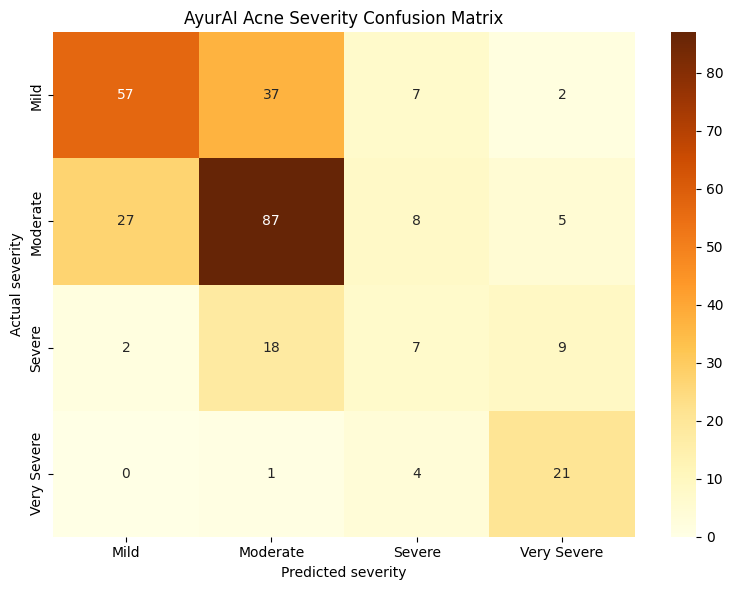

Metrics saved: /content/drive/MyDrive/AyurAI_Model/results/mobilenetv3_test_metrics.json
Confusion matrix saved: /content/drive/MyDrive/AyurAI_Model/results/mobilenetv3_confusion_matrix.png


In [10]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

results_path = os.path.join(base_path, "results")
os.makedirs(results_path, exist_ok=True)

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

test_macro_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)

report = classification_report(
    all_test_labels,
    all_test_predictions,
    target_names=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ],
    output_dict=True
)

metrics = {
    "validation_macro_f1": best_validation_f1,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_macro_f1,
    "classification_report": report
}

metrics_path = os.path.join(
    results_path,
    "mobilenetv3_test_metrics.json"
)

with open(metrics_path, "w") as file:
    json.dump(metrics, file, indent=4)

matrix = confusion_matrix(
    all_test_labels,
    all_test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    xticklabels=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ],
    yticklabels=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ]
)

plt.xlabel("Predicted severity")
plt.ylabel("Actual severity")
plt.title("AyurAI Acne Severity Confusion Matrix")
plt.tight_layout()

matrix_path = os.path.join(
    results_path,
    "mobilenetv3_confusion_matrix.png"
)

plt.savefig(matrix_path, dpi=200)
plt.show()

print("Metrics saved:", metrics_path)
print("Confusion matrix saved:", matrix_path)

Actual: Moderate
Predicted: Moderate
Confidence: 54.83%


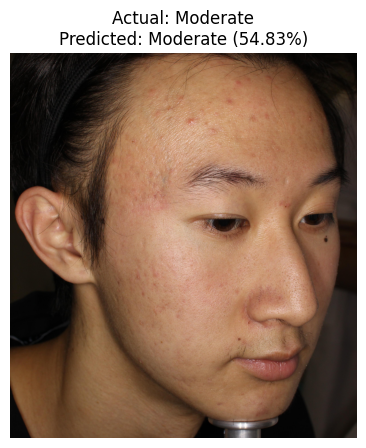

In [11]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

best_checkpoint = torch.load(
    fine_tuned_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

sample = test_df.sample(
    1,
    random_state=7
).iloc[0]

sample_path = os.path.join(
    images_path,
    sample["filename"]
)

original_image = Image.open(
    sample_path
).convert("RGB")

input_tensor = evaluation_transform(
    original_image
).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted_label = probabilities.max(dim=1)

actual_label = int(sample["label"])
predicted_label = predicted_label.item()
confidence = confidence.item()

print("Actual:", label_names[actual_label])
print("Predicted:", label_names[predicted_label])
print("Confidence:", f"{confidence * 100:.2f}%")

plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title(
    f"Actual: {label_names[actual_label]}\n"
    f"Predicted: {label_names[predicted_label]} "
    f"({confidence * 100:.2f}%)"
)
plt.axis("off")
plt.show()

In [12]:
import torch
from sklearn.metrics import accuracy_score

model.eval()

validation_labels = []
validation_predictions = []
validation_confidences = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        validation_labels.extend(labels.tolist())
        validation_predictions.extend(predictions.cpu().tolist())
        validation_confidences.extend(confidences.cpu().tolist())

thresholds = [0.50, 0.60, 0.70, 0.80]

for threshold in thresholds:
    accepted_indices = [
        index
        for index, confidence in enumerate(validation_confidences)
        if confidence >= threshold
    ]

    if accepted_indices:
        accepted_labels = [
            validation_labels[index]
            for index in accepted_indices
        ]

        accepted_predictions = [
            validation_predictions[index]
            for index in accepted_indices
        ]

        accepted_accuracy = accuracy_score(
            accepted_labels,
            accepted_predictions
        )

        coverage = len(accepted_indices) / len(validation_labels)

        print(
            f"Threshold {threshold:.2f} | "
            f"Accepted: {len(accepted_indices)} | "
            f"Coverage: {coverage:.2%} | "
            f"Accuracy: {accepted_accuracy:.2%}"
        )
    else:
        print(
            f"Threshold {threshold:.2f} | "
            "No predictions accepted"
        )

Threshold 0.50 | Accepted: 202 | Coverage: 86.70% | Accuracy: 69.31%
Threshold 0.60 | Accepted: 137 | Coverage: 58.80% | Accuracy: 72.99%
Threshold 0.70 | Accepted: 88 | Coverage: 37.77% | Accuracy: 75.00%
Threshold 0.80 | Accepted: 42 | Coverage: 18.03% | Accuracy: 80.95%


In [13]:
import torch
from sklearn.metrics import accuracy_score

confidence_threshold = 0.60

test_labels_threshold = []
test_predictions_threshold = []
test_confidences = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        test_labels_threshold.extend(labels.tolist())
        test_predictions_threshold.extend(
            predictions.cpu().tolist()
        )
        test_confidences.extend(
            confidences.cpu().tolist()
        )

accepted_indices = [
    index
    for index, confidence in enumerate(test_confidences)
    if confidence >= confidence_threshold
]

accepted_labels = [
    test_labels_threshold[index]
    for index in accepted_indices
]

accepted_predictions = [
    test_predictions_threshold[index]
    for index in accepted_indices
]

accepted_accuracy = accuracy_score(
    accepted_labels,
    accepted_predictions
)

coverage = len(accepted_indices) / len(test_labels_threshold)
uncertain_count = len(test_labels_threshold) - len(accepted_indices)

print("Confidence threshold:", confidence_threshold)
print("Accepted predictions:", len(accepted_indices))
print("Uncertain predictions:", uncertain_count)
print("Test coverage:", f"{coverage:.2%}")
print("Accepted test accuracy:", f"{accepted_accuracy:.2%}")

Confidence threshold: 0.6
Accepted predictions: 187
Uncertain predictions: 105
Test coverage: 64.04%
Accepted test accuracy: 64.17%


In [14]:
import os
import json
import torch

export_path = os.path.join(
    base_path,
    "models",
    "ayurai_acne_mobilenetv3.pt"
)

config_path = os.path.join(
    base_path,
    "models",
    "ayurai_acne_config.json"
)

# Load the saved best model
best_checkpoint = torch.load(
    fine_tuned_model_path,
    map_location="cpu",
    weights_only=False
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model = model.to("cpu")
model.eval()

# Convert to TorchScript
example_input = torch.randn(1, 3, 224, 224)

scripted_model = torch.jit.trace(
    model,
    example_input
)

scripted_model.save(export_path)

model_config = {
    "model_name": "MobileNetV3 Small",
    "task": "Academic acne severity estimation",
    "image_size": 224,
    "classes": {
        "0": "Mild",
        "1": "Moderate",
        "2": "Severe",
        "3": "Very Severe"
    },
    "confidence_threshold": 0.60,
    "normalization_mean": [0.485, 0.456, 0.406],
    "normalization_std": [0.229, 0.224, 0.225],
    "test_accuracy": 0.5890,
    "test_macro_f1": 0.5350,
    "accepted_test_accuracy_at_threshold": 0.6417,
    "disclaimer": (
        "For educational use only. This model does not provide "
        "a medical diagnosis."
    )
}

with open(config_path, "w") as file:
    json.dump(model_config, file, indent=4)

print("Model exported:", export_path)
print("Configuration saved:", config_path)

Model exported: /content/drive/MyDrive/AyurAI_Model/models/ayurai_acne_mobilenetv3.pt
Configuration saved: /content/drive/MyDrive/AyurAI_Model/models/ayurai_acne_config.json


In [15]:
import torch

exported_model = torch.jit.load(
    "/content/drive/MyDrive/AyurAI_Model/models/"
    "ayurai_acne_mobilenetv3.pt",
    map_location="cpu"
)

exported_model.eval()

test_input = evaluation_transform(
    original_image
).unsqueeze(0)

with torch.no_grad():
    output = exported_model(test_input)
    probabilities = torch.softmax(output, dim=1)
    confidence, prediction = probabilities.max(dim=1)

prediction = prediction.item()
confidence = confidence.item()

print("Exported model loaded successfully!")
print("Predicted class:", label_names[prediction])
print("Confidence:", f"{confidence * 100:.2f}%")

if confidence < 0.60:
    print(
        "App result: The model could not provide a reliable "
        "estimate. Try another clear image."
    )
else:
    print(
        "App result: Estimated acne severity:",
        label_names[prediction]
    )

Exported model loaded successfully!
Predicted class: Moderate
Confidence: 54.83%
App result: The model could not provide a reliable estimate. Try another clear image.


In [1]:
import os
from glob import glob
from PIL import Image

images_path = (
    "/content/drive/MyDrive/AyurAI_Model/"
    "dataset/ACNE04/Classification/JPEGImages"
)

image_files = glob(
    os.path.join(images_path, "*.jpg")
)

corrupted_images = []

for image_path in image_files:
    try:
        with Image.open(image_path) as image:
            image.verify()
    except Exception as error:
        corrupted_images.append({
            "filename": os.path.basename(image_path),
            "error": str(error)
        })

print("Images checked:", len(image_files))
print("Corrupted images:", len(corrupted_images))

for item in corrupted_images[:10]:
    print(item)

Images checked: 0
Corrupted images: 0


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os

images_path = (
    "/content/drive/MyDrive/AyurAI_Model/"
    "dataset/ACNE04/Classification/JPEGImages"
)

print("Folder exists:", os.path.exists(images_path))

if os.path.exists(images_path):
    print("Files found:", len(os.listdir(images_path)))

Mounted at /content/drive
Folder exists: True
Files found: 1457


In [3]:
import os
from glob import glob
from PIL import Image

image_files = glob(
    os.path.join(images_path, "*.jpg")
)

corrupted_images = []

for image_path in image_files:
    try:
        with Image.open(image_path) as image:
            image.verify()
    except Exception as error:
        corrupted_images.append({
            "filename": os.path.basename(image_path),
            "error": str(error)
        })

print("Images checked:", len(image_files))
print("Corrupted images:", len(corrupted_images))

for item in corrupted_images[:10]:
    print(item)

Images checked: 1457
Corrupted images: 0


In [4]:
from collections import Counter
from PIL import Image

dimension_counts = Counter()
image_modes = Counter()

for image_path in image_files:
    with Image.open(image_path) as image:
        dimension_counts[image.size] += 1
        image_modes[image.mode] += 1

widths = [width for width, height in dimension_counts.keys()]
heights = [height for width, height in dimension_counts.keys()]

print("Different image dimensions:", len(dimension_counts))
print("Smallest width:", min(widths))
print("Largest width:", max(widths))
print("Smallest height:", min(heights))
print("Largest height:", max(heights))

print("\nMost common dimensions:")
for dimensions, count in dimension_counts.most_common(10):
    print(f"{dimensions}: {count} images")

print("\nImage colour modes:")
for mode, count in image_modes.items():
    print(f"{mode}: {count} images")

Different image dimensions: 155
Smallest width: 143
Largest width: 5184
Smallest height: 155
Largest height: 3456

Most common dimensions:
(3112, 3456): 1107 images
(4912, 3264): 119 images
(5184, 3456): 19 images
(690, 920): 16 images
(1920, 1080): 10 images
(450, 600): 6 images
(194, 259): 6 images
(960, 1280): 4 images
(690, 918): 3 images
(560, 750): 3 images

Image colour modes:
RGB: 1457 images


In [5]:
import hashlib
from collections import defaultdict

hash_groups = defaultdict(list)

for image_path in image_files:
    image_hash = hashlib.sha256()

    with open(image_path, "rb") as file:
        while chunk := file.read(1024 * 1024):
            image_hash.update(chunk)

    hash_groups[image_hash.hexdigest()].append(
        os.path.basename(image_path)
    )

duplicate_groups = [
    filenames
    for filenames in hash_groups.values()
    if len(filenames) > 1
]

duplicate_image_count = sum(
    len(group) - 1
    for group in duplicate_groups
)

print("Images checked:", len(image_files))
print("Exact duplicate groups:", len(duplicate_groups))
print("Extra duplicate images:", duplicate_image_count)

for index, group in enumerate(duplicate_groups[:10], start=1):
    print(f"Duplicate group {index}:", group)

Images checked: 1457
Exact duplicate groups: 38
Extra duplicate images: 38
Duplicate group 1: ['levle0_207.jpg', 'levle0_117.jpg']
Duplicate group 2: ['levle0_98.jpg', 'levle0_99.jpg']
Duplicate group 3: ['levle1_131.jpg', 'levle2_128.jpg']
Duplicate group 4: ['levle1_140.jpg', 'levle1_358.jpg']
Duplicate group 5: ['levle2_152.jpg', 'levle1_22.jpg']
Duplicate group 6: ['levle1_136.jpg', 'levle1_54.jpg']
Duplicate group 7: ['levle2_70.jpg', 'levle2_96.jpg']
Duplicate group 8: ['levle1_164.jpg', 'levle1_291.jpg']
Duplicate group 9: ['levle2_97.jpg', 'levle2_72.jpg']
Duplicate group 10: ['levle1_610.jpg', 'levle1_611.jpg']


In [6]:
import os
import pandas as pd

splits_path = (
    "/content/drive/MyDrive/AyurAI_Model/results/splits"
)

train_split = pd.read_csv(
    os.path.join(splits_path, "train.csv")
)

val_split = pd.read_csv(
    os.path.join(splits_path, "validation.csv")
)

test_split = pd.read_csv(
    os.path.join(splits_path, "test.csv")
)

file_information = {}

for split_name, dataframe in [
    ("train", train_split),
    ("validation", val_split),
    ("test", test_split)
]:
    for _, row in dataframe.iterrows():
        file_information[row["filename"]] = {
            "split": split_name,
            "label": int(row["label"])
        }

cross_split_groups = []
conflicting_label_groups = []

for group in duplicate_groups:
    details = [
        {
            "filename": filename,
            **file_information.get(
                filename,
                {"split": "unknown", "label": "unknown"}
            )
        }
        for filename in group
    ]

    splits = {item["split"] for item in details}
    labels = {item["label"] for item in details}

    if len(splits) > 1:
        cross_split_groups.append(details)

    if len(labels) > 1:
        conflicting_label_groups.append(details)

print("Duplicate groups across different splits:",
      len(cross_split_groups))

print("Duplicate groups with conflicting labels:",
      len(conflicting_label_groups))

print("\nCross-split duplicate details:")
for group in cross_split_groups:
    print(group)

print("\nConflicting-label duplicate details:")
for group in conflicting_label_groups:
    print(group)

Duplicate groups across different splits: 17
Duplicate groups with conflicting labels: 8

Cross-split duplicate details:
[{'filename': 'levle1_140.jpg', 'split': 'train', 'label': 1}, {'filename': 'levle1_358.jpg', 'split': 'test', 'label': 1}]
[{'filename': 'levle2_152.jpg', 'split': 'test', 'label': 2}, {'filename': 'levle1_22.jpg', 'split': 'train', 'label': 1}]
[{'filename': 'levle1_164.jpg', 'split': 'test', 'label': 1}, {'filename': 'levle1_291.jpg', 'split': 'train', 'label': 1}]
[{'filename': 'levle2_97.jpg', 'split': 'train', 'label': 2}, {'filename': 'levle2_72.jpg', 'split': 'validation', 'label': 2}]
[{'filename': 'levle1_574.jpg', 'split': 'train', 'label': 1}, {'filename': 'levle1_572.jpg', 'split': 'test', 'label': 1}]
[{'filename': 'levle1_289.jpg', 'split': 'train', 'label': 1}, {'filename': 'levle1_162.jpg', 'split': 'test', 'label': 1}]
[{'filename': 'levle0_121.jpg', 'split': 'validation', 'label': 0}, {'filename': 'levle1_504.jpg', 'split': 'train', 'label': 1}]
[{

In [7]:
import os
import pandas as pd

audit_path = (
    "/content/drive/MyDrive/AyurAI_Model/results/data_audit"
)

os.makedirs(audit_path, exist_ok=True)

all_metadata = pd.concat(
    [train_split, val_split, test_split],
    ignore_index=True
).drop_duplicates(subset="filename")

all_metadata["content_hash"] = all_metadata["filename"].map(
    {
        filename: image_hash
        for image_hash, filenames in hash_groups.items()
        for filename in filenames
    }
)

clean_records = []
excluded_records = []

for content_hash, group in all_metadata.groupby("content_hash"):
    group = group.sort_values("filename")
    labels = group["label"].unique()

    if len(labels) > 1:
        for _, row in group.iterrows():
            record = row.to_dict()
            record["exclusion_reason"] = (
                "Identical image has conflicting severity labels"
            )
            excluded_records.append(record)

    else:
        clean_records.append(group.iloc[0].to_dict())

        for _, row in group.iloc[1:].iterrows():
            record = row.to_dict()
            record["exclusion_reason"] = (
                "Exact duplicate of another retained image"
            )
            excluded_records.append(record)

clean_df = pd.DataFrame(clean_records)
excluded_df = pd.DataFrame(excluded_records)

clean_manifest_path = os.path.join(
    audit_path,
    "acne04_clean_manifest.csv"
)

excluded_manifest_path = os.path.join(
    audit_path,
    "acne04_excluded_duplicates.csv"
)

clean_df.to_csv(clean_manifest_path, index=False)
excluded_df.to_csv(excluded_manifest_path, index=False)

print("Original images:", len(all_metadata))
print("Clean retained images:", len(clean_df))
print("Excluded images:", len(excluded_df))
print("Conflicting-label exclusions:",
      (excluded_df["exclusion_reason"] ==
       "Identical image has conflicting severity labels").sum())
print("Same-label duplicate exclusions:",
      (excluded_df["exclusion_reason"] ==
       "Exact duplicate of another retained image").sum())

print("\nClean class distribution:")
print(clean_df["label"].value_counts().sort_index())

print("\nClean manifest:", clean_manifest_path)
print("Exclusion record:", excluded_manifest_path)

Original images: 1457
Clean retained images: 1411
Excluded images: 46
Conflicting-label exclusions: 16
Same-label duplicate exclusions: 30

Clean class distribution:
label
0    499
1    608
2    176
3    128
Name: count, dtype: int64

Clean manifest: /content/drive/MyDrive/AyurAI_Model/results/data_audit/acne04_clean_manifest.csv
Exclusion record: /content/drive/MyDrive/AyurAI_Model/results/data_audit/acne04_excluded_duplicates.csv


In [8]:
import os
from sklearn.model_selection import train_test_split

clean_train, clean_temporary = train_test_split(
    clean_df,
    test_size=0.30,
    random_state=42,
    stratify=clean_df["label"]
)

clean_validation, clean_test = train_test_split(
    clean_temporary,
    test_size=0.50,
    random_state=42,
    stratify=clean_temporary["label"]
)

clean_splits_path = (
    "/content/drive/MyDrive/AyurAI_Model/"
    "results/splits_clean"
)

os.makedirs(clean_splits_path, exist_ok=True)

clean_train.to_csv(
    os.path.join(clean_splits_path, "train.csv"),
    index=False
)

clean_validation.to_csv(
    os.path.join(clean_splits_path, "validation.csv"),
    index=False
)

clean_test.to_csv(
    os.path.join(clean_splits_path, "test.csv"),
    index=False
)

print("Clean training images:", len(clean_train))
print("Clean validation images:", len(clean_validation))
print("Clean test images:", len(clean_test))

print("\nTraining distribution:")
print(clean_train["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(clean_validation["label"].value_counts().sort_index())

print("\nTest distribution:")
print(clean_test["label"].value_counts().sort_index())

train_hashes = set(clean_train["content_hash"])
validation_hashes = set(clean_validation["content_hash"])
test_hashes = set(clean_test["content_hash"])

print("\nTrain/validation hash overlap:",
      len(train_hashes & validation_hashes))
print("Train/test hash overlap:",
      len(train_hashes & test_hashes))
print("Validation/test hash overlap:",
      len(validation_hashes & test_hashes))

Clean training images: 987
Clean validation images: 212
Clean test images: 212

Training distribution:
label
0    349
1    425
2    123
3     90
Name: count, dtype: int64

Validation distribution:
label
0    75
1    91
2    27
3    19
Name: count, dtype: int64

Test distribution:
label
0    75
1    92
2    26
3    19
Name: count, dtype: int64

Train/validation hash overlap: 0
Train/test hash overlap: 0
Validation/test hash overlap: 0


## ACNE04 Dataset Record

### Source
Official project repository:
https://github.com/xpwu95/LDL

### Research paper
Xiaoping Wu et al., “Joint Acne Image Grading and Counting via
Label Distribution Learning,” ICCV 2019.

Paper:
https://openaccess.thecvf.com/content_ICCV_2019/html/Wu_Joint_Acne_Image_Grading_and_Counting_via_Label_Distribution_Learning_ICCV_2019_paper.html

### Usage terms
The authors’ repository states that the work is free for academic
usage. For other purposes, users must contact the original author.
No standard open-source dataset licence is clearly specified.

This AyurAI model is an educational, non-diagnostic university
prototype. The ACNE04 images will not be uploaded to GitHub,
redistributed or used commercially.

### Dataset audit
- Original images: 1,457
- Corrupted images: 0
- Exact duplicate groups: 38
- Conflicting-label duplicate groups: 8
- Excluded images: 46
- Clean retained images: 1,411
- Clean split: 987 training, 212 validation and 212 test images
- Duplicate hash overlap between splits: 0
- Image colour mode: RGB
- Original image dimensions vary significantly

In [9]:
import os
import pandas as pd

base_path = "/content/drive/MyDrive/AyurAI_Model"

clean_splits_path = os.path.join(
    base_path,
    "results/splits_clean"
)

train_df = pd.read_csv(
    os.path.join(clean_splits_path, "train.csv")
)

validation_df = pd.read_csv(
    os.path.join(clean_splits_path, "validation.csv")
)

test_df = pd.read_csv(
    os.path.join(clean_splits_path, "test.csv")
)

print("Clean training images:", len(train_df))
print("Clean validation images:", len(validation_df))
print("Clean test images:", len(test_df))

Clean training images: 987
Clean validation images: 212
Clean test images: 212


In [10]:
import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

images_path = os.path.join(
    base_path,
    "dataset/ACNE04/Classification/JPEGImages"
)

image_size = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        image_size,
        scale=(0.80, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class AcneDataset(Dataset):
    def __init__(self, dataframe, images_directory, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_directory = images_directory
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = os.path.join(
            self.images_directory,
            row["filename"]
        )

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

train_dataset = AcneDataset(
    train_df,
    images_path,
    train_transform
)

validation_dataset = AcneDataset(
    validation_df,
    images_path,
    evaluation_transform
)

test_dataset = AcneDataset(
    test_df,
    images_path,
    evaluation_transform
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

batch_images, batch_labels = next(iter(train_loader))

print("Clean datasets and loaders created!")
print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))
print("Batch shape:", batch_images.shape)

Clean datasets and loaders created!
Training samples: 987
Validation samples: 212
Test samples: 212
Batch shape: torch.Size([32, 3, 224, 224])


In [11]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("GPU available:", torch.cuda.is_available())
print("Training device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
Training device: cuda
GPU name: Tesla T4


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

weights = MobileNet_V3_Small_Weights.DEFAULT
clean_model = mobilenet_v3_small(weights=weights)

# Freeze the pretrained feature extractor initially
for parameter in clean_model.features.parameters():
    parameter.requires_grad = False

# Replace the ImageNet classifier with four severity outputs
input_features = clean_model.classifier[3].in_features
clean_model.classifier[3] = nn.Linear(input_features, 4)

clean_model = clean_model.to(device)

class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = len(train_df) / (
    4 * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        clean_model.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Fresh clean model created!")
print("Class counts:", class_counts)
print("Class weights:", class_weights)
print("Output classes:", clean_model.classifier[3].out_features)
print("Device:", next(clean_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 58.7MB/s]


Fresh clean model created!
Class counts: [349 425 123  90]
Class weights: tensor([0.7070, 0.5806, 2.0061, 2.7417], device='cuda:0')
Output classes: 4
Device: cuda:0


In [13]:
import torch
from sklearn.metrics import f1_score

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Keep frozen pretrained features stable
    model.features.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    all_labels = []
    all_predictions = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct_predictions += (
            predictions == labels
        ).sum().item()
        total_predictions += labels.size(0)

        all_labels.extend(labels.cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions
    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1


def evaluate_model(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()
            total_predictions += labels.size(0)

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions
    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1


print("Clean training functions created!")

Clean training functions created!


In [14]:
import os
import torch

number_of_epochs = 12
early_stopping_patience = 4

models_path = os.path.join(base_path, "models")
os.makedirs(models_path, exist_ok=True)

clean_model_path = os.path.join(
    models_path,
    "mobilenetv3_acne_clean_best.pth"
)

clean_history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "validation_f1": []
}

best_validation_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(number_of_epochs):
    train_loss, train_accuracy, train_f1 = train_one_epoch(
        clean_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    validation_loss, validation_accuracy, validation_f1 = (
        evaluate_model(
            clean_model,
            validation_loader,
            criterion,
            device
        )
    )

    scheduler.step(validation_loss)

    clean_history["train_loss"].append(train_loss)
    clean_history["train_accuracy"].append(train_accuracy)
    clean_history["train_f1"].append(train_f1)
    clean_history["validation_loss"].append(validation_loss)
    clean_history["validation_accuracy"].append(validation_accuracy)
    clean_history["validation_f1"].append(validation_f1)

    print(
        f"Epoch {epoch + 1}/{number_of_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: {validation_accuracy:.4f} | "
        f"Validation F1: {validation_f1:.4f}"
    )

    if validation_f1 > best_validation_f1:
        best_validation_f1 = validation_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": clean_model.state_dict(),
                "best_validation_f1": best_validation_f1,
                "classes": {
                    0: "Mild",
                    1: "Moderate",
                    2: "Severe",
                    3: "Very Severe"
                },
                "dataset_version": "ACNE04 cleaned",
                "training_images": len(train_df),
                "validation_images": len(validation_df)
            },
            clean_model_path
        )

        print("Best clean model saved!")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping activated.")
        break

print("\nClean training completed!")
print("Best validation F1:", best_validation_f1)
print("Saved model:", clean_model_path)

Epoch 1/12 | Train loss: 1.0693 | Train accuracy: 0.4488 | Train F1: 0.4395 | Validation loss: 0.9560 | Validation accuracy: 0.5991 | Validation F1: 0.5279
Best clean model saved!
Epoch 2/12 | Train loss: 0.8321 | Train accuracy: 0.5643 | Train F1: 0.5801 | Validation loss: 0.8066 | Validation accuracy: 0.6651 | Validation F1: 0.6476
Best clean model saved!
Epoch 3/12 | Train loss: 0.7589 | Train accuracy: 0.5947 | Train F1: 0.6188 | Validation loss: 0.7576 | Validation accuracy: 0.6557 | Validation F1: 0.6896
Best clean model saved!
Epoch 4/12 | Train loss: 0.6780 | Train accuracy: 0.6667 | Train F1: 0.6765 | Validation loss: 0.8420 | Validation accuracy: 0.6132 | Validation F1: 0.5371
Epoch 5/12 | Train loss: 0.6546 | Train accuracy: 0.6575 | Train F1: 0.6706 | Validation loss: 0.7092 | Validation accuracy: 0.6840 | Validation F1: 0.6913
Best clean model saved!
Epoch 6/12 | Train loss: 0.6759 | Train accuracy: 0.6424 | Train F1: 0.6651 | Validation loss: 0.7024 | Validation accuracy:

In [17]:
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

checkpoint = torch.load(
    clean_model_path,
    map_location=device,
    weights_only=False
)

clean_model.load_state_dict(
    checkpoint["model_state_dict"]
)

clean_model.eval()

test_labels = []
test_predictions = []
test_confidences = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = clean_model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        test_labels.extend(labels.tolist())
        test_predictions.extend(predictions.cpu().tolist())
        test_confidences.extend(confidences.cpu().tolist())

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro"
)

target_names = [
    "Mild",
    "Moderate",
    "Severe",
    "Very Severe"
]

print("Clean test accuracy:", round(test_accuracy, 4))
print("Clean test macro F1:", round(test_macro_f1, 4))

print("\nClassification report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        test_labels,
        test_predictions
    )
)

Clean test accuracy: 0.6698
Clean test macro F1: 0.6407

Classification report:
              precision    recall  f1-score   support

        Mild     0.6905    0.7733    0.7296        75
    Moderate     0.6941    0.6413    0.6667        92
      Severe     0.4545    0.3846    0.4167        26
 Very Severe     0.7143    0.7895    0.7500        19

    accuracy                         0.6698       212
   macro avg     0.6384    0.6472    0.6407       212
weighted avg     0.6653    0.6698    0.6657       212

Confusion matrix:
[[58 17  0  0]
 [25 59  8  0]
 [ 1  9 10  6]
 [ 0  0  4 15]]


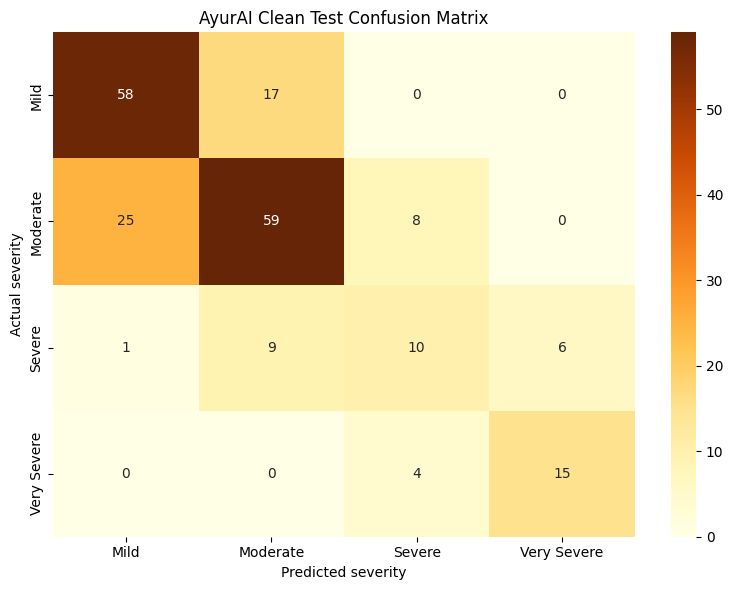

Clean metrics saved: /content/drive/MyDrive/AyurAI_Model/results/clean_model/clean_test_metrics.json
Clean confusion matrix saved: /content/drive/MyDrive/AyurAI_Model/results/clean_model/clean_confusion_matrix.png


In [18]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

clean_results_path = os.path.join(
    base_path,
    "results",
    "clean_model"
)

os.makedirs(clean_results_path, exist_ok=True)

report_dictionary = classification_report(
    test_labels,
    test_predictions,
    target_names=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ],
    output_dict=True,
    zero_division=0
)

clean_metrics = {
    "dataset": "ACNE04 cleaned",
    "original_images": 1457,
    "excluded_images": 46,
    "retained_images": 1411,
    "training_images": 987,
    "validation_images": 212,
    "test_images": 212,
    "duplicate_hash_overlap": 0,
    "best_validation_macro_f1": best_validation_f1,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_macro_f1,
    "classification_report": report_dictionary
}

metrics_path = os.path.join(
    clean_results_path,
    "clean_test_metrics.json"
)

with open(metrics_path, "w") as file:
    json.dump(clean_metrics, file, indent=4)

matrix = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    xticklabels=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ],
    yticklabels=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ]
)

plt.xlabel("Predicted severity")
plt.ylabel("Actual severity")
plt.title("AyurAI Clean Test Confusion Matrix")
plt.tight_layout()

matrix_path = os.path.join(
    clean_results_path,
    "clean_confusion_matrix.png"
)

plt.savefig(matrix_path, dpi=200)
plt.show()

print("Clean metrics saved:", metrics_path)
print("Clean confusion matrix saved:", matrix_path)

In [19]:
import torch
from sklearn.metrics import accuracy_score

clean_model.eval()

validation_labels = []
validation_predictions = []
validation_confidences = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)

        outputs = clean_model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        validation_labels.extend(labels.tolist())
        validation_predictions.extend(
            predictions.cpu().tolist()
        )
        validation_confidences.extend(
            confidences.cpu().tolist()
        )

for threshold in [0.50, 0.60, 0.70, 0.80]:
    accepted_indices = [
        index
        for index, confidence in enumerate(validation_confidences)
        if confidence >= threshold
    ]

    if not accepted_indices:
        print(f"Threshold {threshold:.2f}: no predictions accepted")
        continue

    accepted_labels = [
        validation_labels[index]
        for index in accepted_indices
    ]

    accepted_predictions = [
        validation_predictions[index]
        for index in accepted_indices
    ]

    coverage = len(accepted_indices) / len(validation_labels)

    accepted_accuracy = accuracy_score(
        accepted_labels,
        accepted_predictions
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"Accepted: {len(accepted_indices)} | "
        f"Coverage: {coverage:.2%} | "
        f"Accuracy: {accepted_accuracy:.2%}"
    )

Threshold 0.50 | Accepted: 195 | Coverage: 91.98% | Accuracy: 76.41%
Threshold 0.60 | Accepted: 150 | Coverage: 70.75% | Accuracy: 80.67%
Threshold 0.70 | Accepted: 103 | Coverage: 48.58% | Accuracy: 80.58%
Threshold 0.80 | Accepted: 62 | Coverage: 29.25% | Accuracy: 87.10%


In [20]:
from sklearn.metrics import accuracy_score

confidence_threshold = 0.60

accepted_indices = [
    index
    for index, confidence in enumerate(test_confidences)
    if confidence >= confidence_threshold
]

accepted_labels = [
    test_labels[index]
    for index in accepted_indices
]

accepted_predictions = [
    test_predictions[index]
    for index in accepted_indices
]

accepted_accuracy = accuracy_score(
    accepted_labels,
    accepted_predictions
)

coverage = len(accepted_indices) / len(test_labels)
uncertain_count = len(test_labels) - len(accepted_indices)

print("Confidence threshold:", confidence_threshold)
print("Accepted predictions:", len(accepted_indices))
print("Uncertain predictions:", uncertain_count)
print("Clean test coverage:", f"{coverage:.2%}")
print("Accepted clean test accuracy:", f"{accepted_accuracy:.2%}")

Confidence threshold: 0.6
Accepted predictions: 149
Uncertain predictions: 63
Clean test coverage: 70.28%
Accepted clean test accuracy: 71.81%


In [21]:
import os
import json
import torch

final_model_path = os.path.join(
    base_path,
    "models",
    "ayurai_acne_mobilenetv3_clean.pt"
)

final_config_path = os.path.join(
    base_path,
    "models",
    "ayurai_acne_clean_config.json"
)

# Reload the best clean checkpoint
checkpoint = torch.load(
    clean_model_path,
    map_location="cpu",
    weights_only=False
)

clean_model.load_state_dict(
    checkpoint["model_state_dict"]
)

clean_model = clean_model.to("cpu")
clean_model.eval()

example_input = torch.randn(
    1,
    3,
    224,
    224
)

scripted_model = torch.jit.trace(
    clean_model,
    example_input
)

scripted_model.save(final_model_path)

final_config = {
    "model_name": "MobileNetV3 Small",
    "model_version": "clean-v1",
    "task": "Educational acne-like severity estimation",
    "image_size": 224,
    "classes": {
        "0": "Mild",
        "1": "Moderate",
        "2": "Severe",
        "3": "Very Severe"
    },
    "confidence_threshold": 0.60,
    "normalization_mean": [0.485, 0.456, 0.406],
    "normalization_std": [0.229, 0.224, 0.225],
    "dataset": {
        "name": "ACNE04",
        "original_images": 1457,
        "excluded_images": 46,
        "retained_images": 1411,
        "training_images": 987,
        "validation_images": 212,
        "test_images": 212,
        "duplicate_hash_overlap": 0
    },
    "performance": {
        "validation_macro_f1": 0.7275,
        "test_accuracy": 0.6698,
        "test_macro_f1": 0.6407,
        "threshold_test_coverage": 0.7028,
        "accepted_test_accuracy": 0.7181
    },
    "low_confidence_message": (
        "The model could not produce a reliable result. "
        "Try another clear photo or consult a qualified professional."
    ),
    "disclaimer": (
        "This educational estimate is not a medical diagnosis."
    )
}

with open(final_config_path, "w") as file:
    json.dump(final_config, file, indent=4)

print("Final clean model:", final_model_path)
print("Final configuration:", final_config_path)

Final clean model: /content/drive/MyDrive/AyurAI_Model/models/ayurai_acne_mobilenetv3_clean.pt
Final configuration: /content/drive/MyDrive/AyurAI_Model/models/ayurai_acne_clean_config.json


In [22]:
import os
import torch
from PIL import Image

final_model = torch.jit.load(
    "/content/drive/MyDrive/AyurAI_Model/models/"
    "ayurai_acne_mobilenetv3_clean.pt",
    map_location="cpu"
)

final_model.eval()

sample = test_df.sample(
    1,
    random_state=21
).iloc[0]

sample_image_path = os.path.join(
    images_path,
    sample["filename"]
)

sample_image = Image.open(
    sample_image_path
).convert("RGB")

input_tensor = evaluation_transform(
    sample_image
).unsqueeze(0)

with torch.no_grad():
    output = final_model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, prediction = probabilities.max(dim=1)

prediction = prediction.item()
confidence = confidence.item()

label_names = {
    0: "Mild",
    1: "Moderate",
    2: "Severe",
    3: "Very Severe"
}

print("Final exported model loaded successfully!")
print("Actual class:", label_names[int(sample["label"])])
print("Predicted class:", label_names[prediction])
print("Model score:", f"{confidence * 100:.2f}%")

if confidence < 0.60:
    print(
        "App result: The model could not produce a reliable result. "
        "Try another clear photo or consult a qualified professional."
    )
else:
    print(
        "App result: The model detected an acne-like appearance "
        f"with an estimated {label_names[prediction].lower()} severity. "
        "This result is educational and is not a medical diagnosis."
    )

Final exported model loaded successfully!
Actual class: Mild
Predicted class: Mild
Model score: 81.68%
App result: The model detected an acne-like appearance with an estimated mild severity. This result is educational and is not a medical diagnosis.


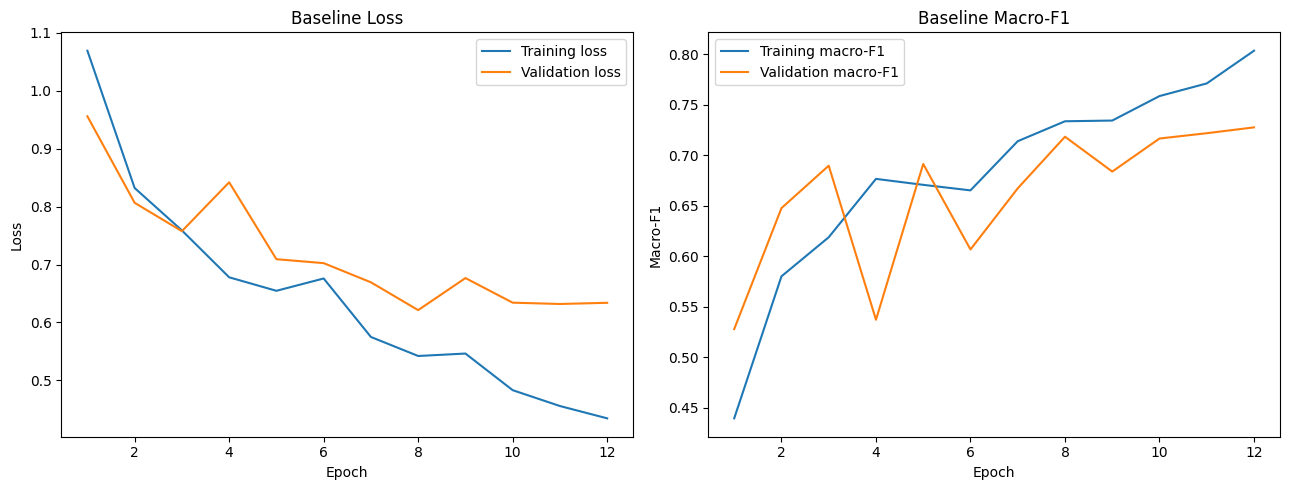

History saved: /content/drive/MyDrive/AyurAI_Model/results/clean_model/baseline_training_history.json
Training curves saved: /content/drive/MyDrive/AyurAI_Model/results/clean_model/baseline_training_curves.png


In [24]:
import os
import json
import matplotlib.pyplot as plt

baseline_results_path = os.path.join(
    base_path,
    "results",
    "clean_model"
)

os.makedirs(baseline_results_path, exist_ok=True)

history_path = os.path.join(
    baseline_results_path,
    "baseline_training_history.json"
)

with open(history_path, "w") as file:
    json.dump(clean_history, file, indent=4)

epochs = range(
    1,
    len(clean_history["train_loss"]) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    epochs,
    clean_history["train_loss"],
    label="Training loss"
)

axes[0].plot(
    epochs,
    clean_history["validation_loss"],
    label="Validation loss"
)

axes[0].set_title("Baseline Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    epochs,
    clean_history["train_f1"],
    label="Training macro-F1"
)

axes[1].plot(
    epochs,
    clean_history["validation_f1"],
    label="Validation macro-F1"
)

axes[1].set_title("Baseline Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()

plt.tight_layout()

curves_path = os.path.join(
    baseline_results_path,
    "baseline_training_curves.png"
)

plt.savefig(curves_path, dpi=200)
plt.show()

print("History saved:", history_path)
print("Training curves saved:", curves_path)

In [25]:
import torch
import torch.optim as optim
from sklearn.metrics import f1_score

# Restore the best clean baseline
checkpoint = torch.load(
    clean_model_path,
    map_location=device,
    weights_only=False
)

clean_model.load_state_dict(
    checkpoint["model_state_dict"]
)

clean_model = clean_model.to(device)

# Freeze every feature block
for parameter in clean_model.features.parameters():
    parameter.requires_grad = False

# Unfreeze only the final feature block
for parameter in clean_model.features[-1].parameters():
    parameter.requires_grad = True

# Keep the classifier trainable
for parameter in clean_model.classifier.parameters():
    parameter.requires_grad = True

fine_tune_optimizer = optim.AdamW(
    [
        {
            "params": clean_model.features[-1].parameters(),
            "lr": 0.00001
        },
        {
            "params": clean_model.classifier.parameters(),
            "lr": 0.0001
        }
    ],
    weight_decay=0.0001
)

fine_tune_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    fine_tune_optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

def train_fine_tune_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Frozen blocks stay in evaluation mode
    for block in model.features[:-1]:
        block.eval()

    # Final unfrozen block learns
    model.features[-1].train()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    all_labels = []
    all_predictions = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct_predictions += (
            predictions == labels
        ).sum().item()
        total_predictions += labels.size(0)

        all_labels.extend(labels.cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions
    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1

trainable_parameters = sum(
    parameter.numel()
    for parameter in clean_model.parameters()
    if parameter.requires_grad
)

print("Clean fine-tuning prepared!")
print("Baseline validation F1:",
      checkpoint["best_validation_f1"])
print("Trainable parameters:", trainable_parameters)
print("Device:", next(clean_model.parameters()).device)

Clean fine-tuning prepared!
Baseline validation F1: 0.7274881781249223
Trainable parameters: 651396
Device: cuda:0


In [26]:
import os
import torch

fine_tune_epochs = 6
early_stopping_patience = 3

fine_tuned_path = os.path.join(
    models_path,
    "mobilenetv3_acne_clean_finetuned_best.pth"
)

best_fine_tune_f1 = checkpoint["best_validation_f1"]
epochs_without_improvement = 0

fine_tune_history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "validation_f1": []
}

# Initially preserve the best baseline in the new file
torch.save(
    {
        "model_state_dict": clean_model.state_dict(),
        "best_validation_f1": best_fine_tune_f1,
        "stage": "clean baseline retained"
    },
    fine_tuned_path
)

for epoch in range(fine_tune_epochs):
    train_loss, train_accuracy, train_f1 = (
        train_fine_tune_epoch(
            clean_model,
            train_loader,
            criterion,
            fine_tune_optimizer,
            device
        )
    )

    validation_loss, validation_accuracy, validation_f1 = (
        evaluate_model(
            clean_model,
            validation_loader,
            criterion,
            device
        )
    )

    fine_tune_scheduler.step(validation_loss)

    fine_tune_history["train_loss"].append(train_loss)
    fine_tune_history["train_accuracy"].append(train_accuracy)
    fine_tune_history["train_f1"].append(train_f1)
    fine_tune_history["validation_loss"].append(validation_loss)
    fine_tune_history["validation_accuracy"].append(
        validation_accuracy
    )
    fine_tune_history["validation_f1"].append(validation_f1)

    print(
        f"Fine-tune epoch {epoch + 1}/{fine_tune_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: {validation_accuracy:.4f} | "
        f"Validation F1: {validation_f1:.4f}"
    )

    if validation_f1 > best_fine_tune_f1:
        best_fine_tune_f1 = validation_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": clean_model.state_dict(),
                "best_validation_f1": best_fine_tune_f1,
                "stage": "clean fine-tuned"
            },
            fine_tuned_path
        )

        print("Improved fine-tuned model saved!")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping activated.")
        break

print("\nFine-tuning completed!")
print("Baseline validation F1:",
      checkpoint["best_validation_f1"])
print("Best validation F1 after fine-tuning:",
      best_fine_tune_f1)
print("Saved checkpoint:", fine_tuned_path)

Fine-tune epoch 1/6 | Train loss: 0.6928 | Train accuracy: 0.6677 | Train F1: 0.6677 | Validation loss: 0.6369 | Validation accuracy: 0.7642 | Validation F1: 0.7480
Improved fine-tuned model saved!
Fine-tune epoch 2/6 | Train loss: 0.5168 | Train accuracy: 0.7477 | Train F1: 0.7641 | Validation loss: 0.6140 | Validation accuracy: 0.7547 | Validation F1: 0.7447
Fine-tune epoch 3/6 | Train loss: 0.5147 | Train accuracy: 0.7356 | Train F1: 0.7498 | Validation loss: 0.6189 | Validation accuracy: 0.7217 | Validation F1: 0.6980
Fine-tune epoch 4/6 | Train loss: 0.5116 | Train accuracy: 0.7305 | Train F1: 0.7482 | Validation loss: 0.6193 | Validation accuracy: 0.7264 | Validation F1: 0.7021
Early stopping activated.

Fine-tuning completed!
Baseline validation F1: 0.7274881781249223
Best validation F1 after fine-tuning: 0.7479583206112228
Saved checkpoint: /content/drive/MyDrive/AyurAI_Model/models/mobilenetv3_acne_clean_finetuned_best.pth


In [28]:
import torch

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

fine_tuned_checkpoint = torch.load(
    fine_tuned_path,
    map_location=device,
    weights_only=False
)

clean_model.load_state_dict(
    fine_tuned_checkpoint["model_state_dict"]
)

clean_model.eval()

final_test_labels = []
final_test_predictions = []
final_test_confidences = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = clean_model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        final_test_labels.extend(labels.tolist())
        final_test_predictions.extend(
            predictions.cpu().tolist()
        )
        final_test_confidences.extend(
            confidences.cpu().tolist()
        )

final_test_accuracy = accuracy_score(
    final_test_labels,
    final_test_predictions
)

final_test_macro_f1 = f1_score(
    final_test_labels,
    final_test_predictions,
    average="macro"
)

target_names = [
    "Mild",
    "Moderate",
    "Severe",
    "Very Severe"
]

print(
    "Fine-tuned test accuracy:",
    round(final_test_accuracy, 4)
)

print(
    "Fine-tuned test macro F1:",
    round(final_test_macro_f1, 4)
)

print("\nClassification report:")

print(
    classification_report(
        final_test_labels,
        final_test_predictions,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        final_test_labels,
        final_test_predictions
    )
)

Fine-tuned test accuracy: 0.6415
Fine-tuned test macro F1: 0.5912

Classification report:
              precision    recall  f1-score   support

        Mild     0.6824    0.7733    0.7250        75
    Moderate     0.6867    0.6196    0.6514        92
      Severe     0.3793    0.4231    0.4000        26
 Very Severe     0.6667    0.5263    0.5882        19

    accuracy                         0.6415       212
   macro avg     0.6038    0.5856    0.5912       212
weighted avg     0.6457    0.6415    0.6410       212

Confusion matrix:
[[58 17  0  0]
 [26 57  9  0]
 [ 1  9 11  5]
 [ 0  0  9 10]]


In [29]:
import os
import json

comparison = {
    "baseline": {
        "validation_macro_f1": 0.7274881781,
        "test_accuracy": 0.6698,
        "test_macro_f1": 0.6407
    },
    "fine_tuned": {
        "validation_macro_f1": 0.7479583206,
        "test_accuracy": 0.6415,
        "test_macro_f1": 0.5912
    },
    "selected_model": "baseline",
    "selected_model_file": "ayurai_acne_mobilenetv3_clean.pt",
    "reason": (
        "Fine-tuning improved validation macro-F1 but reduced "
        "performance on the clean test split."
    ),
    "important_note": (
        "The test split has now been used to compare model variants. "
        "Do not continue repeatedly changing settings based on these "
        "test results. Future rigorous comparisons should use "
        "cross-validation or a new untouched holdout set."
    )
}

comparison_path = os.path.join(
    base_path,
    "results",
    "clean_model",
    "baseline_vs_finetuned.json"
)

with open(comparison_path, "w") as file:
    json.dump(comparison, file, indent=4)

fine_tune_history_path = os.path.join(
    base_path,
    "results",
    "clean_model",
    "fine_tune_history.json"
)

with open(fine_tune_history_path, "w") as file:
    json.dump(fine_tune_history, file, indent=4)

print("Comparison saved:", comparison_path)
print("Fine-tuning history saved:", fine_tune_history_path)
print("Selected model: ayurai_acne_mobilenetv3_clean.pt")

Comparison saved: /content/drive/MyDrive/AyurAI_Model/results/clean_model/baseline_vs_finetuned.json
Fine-tuning history saved: /content/drive/MyDrive/AyurAI_Model/results/clean_model/fine_tune_history.json
Selected model: ayurai_acne_mobilenetv3_clean.pt


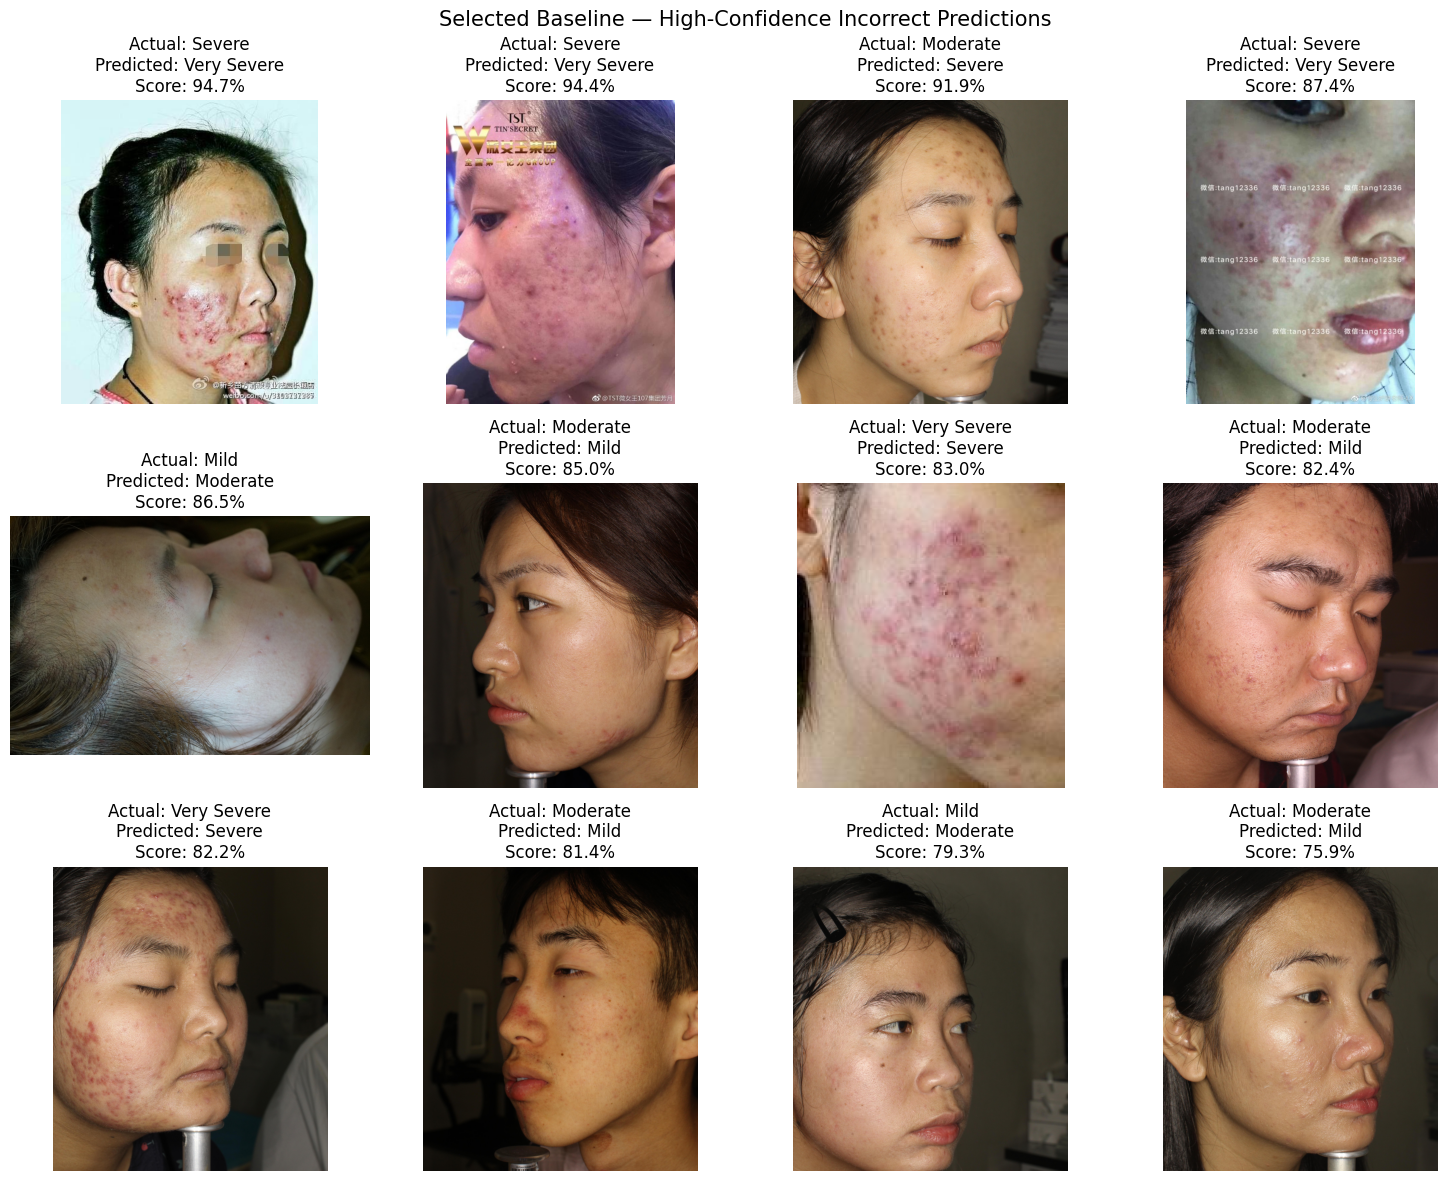

Total incorrect predictions: 70
Incorrect prediction CSV: /content/drive/MyDrive/AyurAI_Model/results/clean_model/incorrect_predictions.csv
Example grid: /content/drive/MyDrive/AyurAI_Model/results/clean_model/incorrect_prediction_examples.png


In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

label_names = {
    0: "Mild",
    1: "Moderate",
    2: "Severe",
    3: "Very Severe"
}

incorrect_records = []

for index, (
    actual,
    predicted,
    confidence
) in enumerate(
    zip(
        test_labels,
        test_predictions,
        test_confidences
    )
):
    if actual != predicted:
        row = test_df.iloc[index]

        incorrect_records.append({
            "filename": row["filename"],
            "actual_label": actual,
            "actual_class": label_names[actual],
            "predicted_label": predicted,
            "predicted_class": label_names[predicted],
            "confidence": confidence
        })

incorrect_df = pd.DataFrame(
    incorrect_records
).sort_values(
    "confidence",
    ascending=False
).reset_index(drop=True)

incorrect_csv_path = os.path.join(
    base_path,
    "results",
    "clean_model",
    "incorrect_predictions.csv"
)

incorrect_df.to_csv(
    incorrect_csv_path,
    index=False
)

examples = incorrect_df.head(12)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(15, 12)
)

for axis, (_, row) in zip(
    axes.flatten(),
    examples.iterrows()
):
    image_path = os.path.join(
        images_path,
        row["filename"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    axis.imshow(image)
    axis.set_title(
        f"Actual: {row['actual_class']}\n"
        f"Predicted: {row['predicted_class']}\n"
        f"Score: {row['confidence'] * 100:.1f}%"
    )
    axis.axis("off")

plt.suptitle(
    "Selected Baseline — High-Confidence Incorrect Predictions",
    fontsize=15
)

plt.tight_layout()

incorrect_grid_path = os.path.join(
    base_path,
    "results",
    "clean_model",
    "incorrect_prediction_examples.png"
)

plt.savefig(
    incorrect_grid_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Total incorrect predictions:", len(incorrect_df))
print("Incorrect prediction CSV:", incorrect_csv_path)
print("Example grid:", incorrect_grid_path)

## Evaluation Limitations and Possible Bias

### Final selected baseline results

- Test images: 212
- Test accuracy: 66.98%
- Test macro-F1: 64.07%
- Incorrect predictions: 70
- Mild F1: 72.96%
- Moderate F1: 66.67%
- Severe F1: 41.67%
- Very Severe F1: 75.00%

The Severe category produced the weakest result. The model sometimes
confused Severe images with Moderate or Very Severe images.

### Confidence limitation

Some incorrect predictions received high softmax scores. Therefore,
the displayed score must not be described as a medically calibrated
probability. A 0.60 rejection threshold reduces some unreliable
results, but does not guarantee correctness.

### Dataset limitations

- ACNE04 is relatively small.
- The four classes are imbalanced.
- The Severe and Very Severe categories contain fewer images.
- 38 exact duplicate groups were discovered.
- Eight duplicate groups contained conflicting severity labels.
- Forty-six problematic images were excluded through metadata.
- Original image dimensions and image quality vary significantly.
- Some images contain watermarks, text, blur or inconsistent lighting.
- ACNE04 does not provide a reliable clear/no-acne class.
- The images may not represent ordinary mobile-phone selfies.
- Subject identifiers are not provided, so person-independent splitting
  could not be fully verified.
- Skin-tone, ethnicity, age and gender metadata are not provided.
- The dataset's demographic and geographic representation is unclear.

### Skin-tone evaluation limitation

The images appear to contain some visible variation in skin tone and
lighting. However, ACNE04 does not provide validated skin-tone labels.
Lighting, camera settings and redness can also change apparent skin
colour. Therefore, this project does not assign demographic identities
or report quantitative fairness performance across skin-tone groups.

A future evaluation should use consented data with documented skin-tone
labels and enough examples in every subgroup.

### Appropriate use

This model estimates an acne-like visual severity category for an
educational university prototype. It is not a medical device and does
not diagnose acne or recommend clinical treatment. Low-confidence or
concerning results should direct users to retake a clear photograph or
consult a qualified professional.

The ACNE04 images must not be redistributed or uploaded to GitHub.

In [31]:
import os
import torch
from PIL import Image, UnidentifiedImageError
from torchvision import transforms

model_path = (
    "/content/drive/MyDrive/AyurAI_Model/models/"
    "ayurai_acne_mobilenetv3_clean.pt"
)

prediction_model = torch.jit.load(
    model_path,
    map_location="cpu"
)

prediction_model.eval()

validation_preprocessing = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class_names = [
    "Mild",
    "Moderate",
    "Severe",
    "Very Severe"
]

allowed_formats = {
    "JPEG",
    "PNG",
    "WEBP"
}

def predict_acne_severity(
    image_path,
    confidence_threshold=0.60
):
    if not os.path.isfile(image_path):
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    try:
        with Image.open(image_path) as check_image:
            image_format = check_image.format

            if image_format not in allowed_formats:
                raise ValueError(
                    "Only JPG, JPEG, PNG and WebP images are supported."
                )

            check_image.verify()

        image = Image.open(image_path).convert("RGB")

    except UnidentifiedImageError as error:
        raise ValueError(
            "The selected file is not a valid image."
        ) from error

    input_tensor = validation_preprocessing(
        image
    ).unsqueeze(0)

    with torch.no_grad():
        logits = prediction_model(input_tensor)
        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    predicted_index = int(
        torch.argmax(probabilities).item()
    )

    model_score = float(
        probabilities[predicted_index].item()
    )

    probability_results = {
        class_names[index]: round(
            float(probability.item()),
            4
        )
        for index, probability in enumerate(probabilities)
    }

    if model_score < confidence_threshold:
        return {
            "status": "uncertain",
            "estimated_category": None,
            "model_score": round(model_score, 4),
            "probabilities": probability_results,
            "message": (
                "The model could not produce a reliable result. "
                "Try another clear photo or consult a qualified "
                "professional."
            ),
            "disclaimer": (
                "This educational result is not a medical diagnosis."
            )
        }

    predicted_category = class_names[predicted_index]

    return {
        "status": "estimated",
        "estimated_category": predicted_category,
        "model_score": round(model_score, 4),
        "probabilities": probability_results,
        "message": (
            "The model detected an acne-like appearance with an "
            f"estimated {predicted_category.lower()} severity."
        ),
        "disclaimer": (
            "This educational result is not a medical diagnosis."
        )
    }

print("Prediction function created successfully!")
print("Supported formats: JPG, JPEG, PNG and WebP")
print("Confidence threshold: 0.60")

Prediction function created successfully!
Supported formats: JPG, JPEG, PNG and WebP
Confidence threshold: 0.60


In [32]:
from google.colab import files

uploaded_files = files.upload()

uploaded_filename = next(
    iter(uploaded_files)
)

print("Uploaded image:", uploaded_filename)

Saving WhatsApp Image 2025-02-21 at 10.43.34_b8c26284.jpg to WhatsApp Image 2025-02-21 at 10.43.34_b8c26284.jpg
Uploaded image: WhatsApp Image 2025-02-21 at 10.43.34_b8c26284.jpg


In [33]:
import json

prediction_result = predict_acne_severity(
    uploaded_filename,
    confidence_threshold=0.60
)

print(
    json.dumps(
        prediction_result,
        indent=4
    )
)

{
    "status": "uncertain",
    "estimated_category": null,
    "model_score": 0.5074,
    "probabilities": {
        "Mild": 0.5074,
        "Moderate": 0.407,
        "Severe": 0.0029,
        "Very Severe": 0.0827
    },
    "message": "The model could not produce a reliable result. Try another clear photo or consult a qualified professional.",
    "disclaimer": "This educational result is not a medical diagnosis."
}


In [34]:
import os
import json
import shutil
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from zoneinfo import ZoneInfo
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

models_path = os.path.join(
    base_path,
    "models"
)

results_path = os.path.join(
    base_path,
    "results"
)

os.makedirs(models_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

# --------------------------------------------------
# 1. Standard model filename
# --------------------------------------------------

source_model_path = os.path.join(
    models_path,
    "ayurai_acne_mobilenetv3_clean.pt"
)

best_model_path = os.path.join(
    models_path,
    "best_model.pt"
)

shutil.copy2(
    source_model_path,
    best_model_path
)

# --------------------------------------------------
# 2. Classification report
# --------------------------------------------------

report = classification_report(
    test_labels,
    test_predictions,
    target_names=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ],
    output_dict=True,
    zero_division=0
)

classification_report_path = os.path.join(
    results_path,
    "classification_report.json"
)

with open(
    classification_report_path,
    "w"
) as file:
    json.dump(report, file, indent=4)

# --------------------------------------------------
# 3. Confusion matrix
# --------------------------------------------------

matrix = confusion_matrix(
    test_labels,
    test_predictions
)

confusion_matrix_path = os.path.join(
    results_path,
    "confusion_matrix.png"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    xticklabels=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ],
    yticklabels=[
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ]
)

plt.xlabel("Predicted severity")
plt.ylabel("Actual severity")
plt.title("AyurAI Test Confusion Matrix")
plt.tight_layout()
plt.savefig(
    confusion_matrix_path,
    dpi=200
)
plt.close()

# --------------------------------------------------
# 4. Training curves
# --------------------------------------------------

source_curves_path = os.path.join(
    results_path,
    "clean_model",
    "baseline_training_curves.png"
)

training_curves_path = os.path.join(
    results_path,
    "training_curves.png"
)

shutil.copy2(
    source_curves_path,
    training_curves_path
)

# --------------------------------------------------
# 5. All test predictions
# --------------------------------------------------

test_predictions_df = pd.DataFrame({
    "filename": test_df["filename"].tolist(),
    "actual_label": test_labels,
    "actual_class": [
        ["Mild", "Moderate", "Severe", "Very Severe"][label]
        for label in test_labels
    ],
    "predicted_label": test_predictions,
    "predicted_class": [
        ["Mild", "Moderate", "Severe", "Very Severe"][label]
        for label in test_predictions
    ],
    "model_score": test_confidences
})

test_predictions_df["correct"] = (
    test_predictions_df["actual_label"]
    == test_predictions_df["predicted_label"]
)

test_predictions_df["status_at_0.60"] = (
    test_predictions_df["model_score"]
    .apply(
        lambda score: "estimated"
        if score >= 0.60
        else "uncertain"
    )
)

test_predictions_path = os.path.join(
    results_path,
    "test_predictions.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False
)

# --------------------------------------------------
# 6. Training metadata
# --------------------------------------------------

metadata = {
    "project": "AyurAI",
    "dataset_name": "ACNE04",
    "dataset_version": "Original authors' 2019 release, cleaned locally",
    "original_images": 1457,
    "excluded_images": 46,
    "retained_images": 1411,
    "training_images": 987,
    "validation_images": 212,
    "test_images": 212,
    "training_date_sri_lanka": datetime.now(
        ZoneInfo("Asia/Colombo")
    ).isoformat(),
    "model_architecture": "MobileNetV3 Small",
    "pretrained_weights": "ImageNet DEFAULT",
    "class_names": [
        "Mild",
        "Moderate",
        "Severe",
        "Very Severe"
    ],
    "image_size": [224, 224],
    "batch_size": 32,
    "optimizer": "AdamW",
    "classifier_learning_rate": 0.001,
    "split_random_seed": 42,
    "training_random_seed": None,
    "training_seed_note": (
        "A global Python, NumPy and PyTorch training seed "
        "was not explicitly fixed for this run."
    ),
    "best_epoch": 12,
    "best_validation_macro_f1": 0.7274881781,
    "test_accuracy": 0.6698,
    "test_macro_f1": 0.6407,
    "confidence_threshold": 0.60,
    "pytorch_version": torch.__version__,
    "selected_model": "baseline classifier-head model",
    "fine_tuned_model_selected": False,
    "intended_use": (
        "Educational, non-diagnostic university prototype"
    )
}

metadata_path = os.path.join(
    results_path,
    "training_metadata.json"
)

with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=4)

print("Evidence package created:")
print("1.", best_model_path)
print("2.", classification_report_path)
print("3.", confusion_matrix_path)
print("4.", training_curves_path)
print("5.", test_predictions_path)
print("6.", metadata_path)

Evidence package created:
1. /content/drive/MyDrive/AyurAI_Model/models/best_model.pt
2. /content/drive/MyDrive/AyurAI_Model/results/classification_report.json
3. /content/drive/MyDrive/AyurAI_Model/results/confusion_matrix.png
4. /content/drive/MyDrive/AyurAI_Model/results/training_curves.png
5. /content/drive/MyDrive/AyurAI_Model/results/test_predictions.csv
6. /content/drive/MyDrive/AyurAI_Model/results/training_metadata.json


In [35]:
import os
import json
import pandas as pd

evidence_files = [
    best_model_path,
    classification_report_path,
    confusion_matrix_path,
    training_curves_path,
    test_predictions_path,
    metadata_path
]

all_files_valid = True

for file_path in evidence_files:
    exists = os.path.isfile(file_path)
    size = os.path.getsize(file_path) if exists else 0

    print(
        os.path.basename(file_path),
        "| Exists:", exists,
        "| Size:", size, "bytes"
    )

    if not exists or size == 0:
        all_files_valid = False

with open(classification_report_path, "r") as file:
    saved_report = json.load(file)

with open(metadata_path, "r") as file:
    saved_metadata = json.load(file)

saved_predictions = pd.read_csv(
    test_predictions_path
)

print("\nPrediction rows:", len(saved_predictions))
print("Recorded architecture:",
      saved_metadata["model_architecture"])
print("Recorded PyTorch version:",
      saved_metadata["pytorch_version"])
print("Best recorded epoch:",
      saved_metadata["best_epoch"])
print("All evidence files valid:",
      all_files_valid)

best_model.pt | Exists: True | Size: 6577553 bytes
classification_report.json | Exists: True | Size: 1038 bytes
confusion_matrix.png | Exists: True | Size: 73826 bytes
training_curves.png | Exists: True | Size: 151262 bytes
test_predictions.csv | Exists: True | Size: 14535 bytes
training_metadata.json | Exists: True | Size: 1247 bytes

Prediction rows: 212
Recorded architecture: MobileNetV3 Small
Recorded PyTorch version: 2.11.0+cu128
Best recorded epoch: 12
All evidence files valid: True
